In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize, minimize_scalar

sys.path.append('src')
plt.style.use("ggplot")

from utils import neg_log_likelihood, normal_normal_posterior

g++ not available, if using conda: `conda install gxx`


# Introduction to Bayesian Statistics

In the previous notebooks, every method we used was built solely on observations. That is the frequentist view. Bayesian statistics, by contrast, lets us incorporate our prior beliefs into statistical models. This can be really handy when the number of observations is small, or the domain knowledge is high.
 
## Bayes Theorem

Bayes theorem is defined as: (*)

$P(\theta \mid D) = \frac{P(D \mid \theta) \, P(\theta)}{P(D)}$

where

* $P(\theta)$ is called "Prior". It refers to what we believe about data before seeing it.
* $P(D \mid \theta)$ is called "Likelihood". It shows how probable the observed data is, given $\theta$.
* $P(D)$ is called "Evidence". It refers to the total probability of the data across all possible $\theta$.
* $P(\theta \mid D)$ is defined as "Posterior". It corresponds to the updated belief about $\theta$ after seeing it.  

Since the evidence $P(D)$ is just a normalizing constant (it doesn't depend on $\theta$), we often write:

$P(\theta \mid D) \propto P(D \mid \theta) \, P(\theta)$

(*) **Interesting fact**: The mathematical formula of Bayes theorem was formally derived by Laplace.


## A First Bayesian Model

Bayes theorem tells us how to combine a prior with data, but it stays abstract until we use it. Let's start with the smallest useful example.

Selecting a proper prior is usually the hardest part of a Bayesian model, since it is a term unique to the Bayesian school of thought. One convenient way out is to borrow the prior from a larger dataset we already trust.

**Example**

Say we want to model the mean height of a small city. We have some data, but it is small ($n = 12$). On its own, such a small sample gives an unreliable estimate. Height is distributed roughly the same across a country though, so we can use the height data of the whole country as a prior.

$n_{city} = 12$

$n_{country} = 2000$

$\text{small city} \sim \mathcal{N}(158, 12^2)$

$\text{country} \sim \mathcal{N}(165, 10^2)$


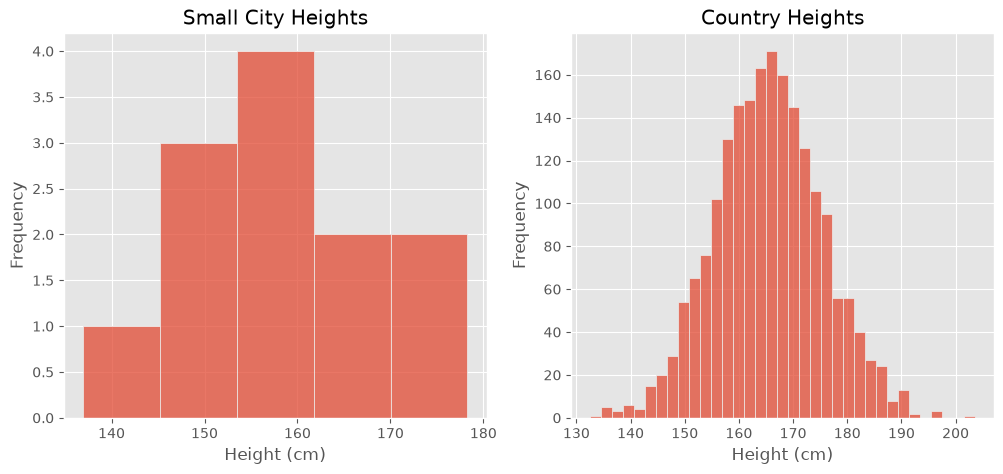

In [ ]:
small_city_data = stats.norm.rvs(loc = 158, scale = 12, size = 12, random_state = 7)
country_data = stats.norm.rvs(loc = 165, scale = 10, size = 2000, random_state = 42)

fig,ax = plt.subplots(ncols = 2, nrows = 1, figsize = (12, 5))
sns.histplot(small_city_data, ax=ax[0])
ax[0].set_title("Small City Heights")
ax[0].set_xlabel("Height (cm)")
ax[0].set_ylabel("Frequency")

sns.histplot(country_data, ax=ax[1])
ax[1].set_title("Country Heights")
ax[1].set_xlabel("Height (cm)")
ax[1].set_ylabel("Frequency")

plt.show()


### Estimating the Prior with Maximum Likelihood

The country distribution is clearly normal. Therefore we can use a normal fit for MLE maximization.

Luckily there is an analytical solution for MLE maximization of a normal distribution. Use sample parameters as population parameters:

$\mu \leftarrow \bar{x}$

$\sigma^2 \leftarrow \hat{\sigma}^2$


In [3]:
country_mean, country_std = stats.norm.fit(country_data)

print(f"Country mean: {country_mean:.2f} cm")
print(f"Country std:  {country_std:.2f} cm")

Country mean: 165.45 cm
Country std:  9.88 cm


What if the data is not that good? What would we do then?

The answer is to iterate through different parameters and pick the one which maximizes the likelihood.

In [4]:
country_result = minimize(neg_log_likelihood, x0=[0, 1], method = 'Nelder-Mead', args=(country_data,))
print("Optimization result")
print("Estimated mean (mu):", country_result.x[0])
print("Estimated std (sigma):", country_result.x[1])

Optimization result
Estimated mean (mu): 165.45085751252225
Estimated std (sigma): 9.882159108725375


### Combining the Prior and the Data (Conjugate Priors)

Combining two distributions can be hard. Fortunately, there are distribution pairs that make this straightforward. They are called *conjugate* pairs (when the prior belongs to the same distributional family as the posterior). Therefore, when choosing priors, it is always a good practice to select conjugate ones. Three common conjugate families are:

* Beta — Binomial
* Normal — Normal
* Gamma — Poisson


Since we selected a normal prior, we can analytically obtain the parameters of the posterior distribution.

The formulas:

$$\mu_{\text{post}} = \frac{\frac{\mu_0}{\sigma_0^2} + \frac{n\bar{x}}{\sigma^2}}{\frac{1}{\sigma_0^2} + \frac{n}{\sigma^2}}$$

$$\sigma_{\text{post}}^2 = \frac{1}{\frac{1}{\sigma_0^2} + \frac{n}{\sigma^2}}$$

where $\mu_0, \sigma_0$ are the prior parameters, $\bar{x}$ is the sample mean, $\sigma$ is the known data standard deviation, and $n$ is the sample size.

A very common mistake is to plug the country standard deviation (10 cm) straight into $\sigma_0$. But 10 cm is how much *individual people* differ from each other, whereas $\sigma_0$ has to describe how uncertain we are about the *city's mean*. Those refer to different things. We will figure out the value of $\sigma_0$ by looking at the data itself in Empirical Bayes, but for now we need to define it separately, and completely based on our beliefs. For this example, assuming the city mean is most likely within $\pm 6$ cm of the national mean is a reasonable claim. That range spans about two standard deviations, so we set $\sigma_0 = 3$.


In [ ]:
prior_mean = country_mean
prior_std = 3.0 

obs_var = small_city_data.var()
obs_std = small_city_data.std()

posterior = normal_normal_posterior(observations = small_city_data,
                                    prior_mean = prior_mean,
                                    prior_variance = prior_std**2,
                                    observation_variance = obs_var)

posterior_mean = posterior["mean"]
posterior_std = posterior["std"]

prior_weight = (1 / prior_std**2) / (1 / prior_std**2 + len(small_city_data) / obs_var)

print(f"Prior mean:      {prior_mean:.2f} cm")
print(f"Sample mean:     {small_city_data.mean():.2f} cm")
print(f"Posterior mean:  {posterior_mean:.2f} cm (std {posterior_std:.2f})")
print(f"Prior weight:    {prior_weight:.1%}")


Posterior        : N(161.6465, 2.1069²)
Posterior mean   : 161.6465
95% HDI          : (157.5684, 165.8294)
Prior mean:      165.45 cm
Sample mean:     157.94 cm
Posterior mean:  161.65 cm (std 2.11)
Prior weight:    49.3%


We can visualize how the posterior combines the two sources of information. The prior is centered on the country mean, the likelihood on the small city sample mean, and the posterior is formed between those two.


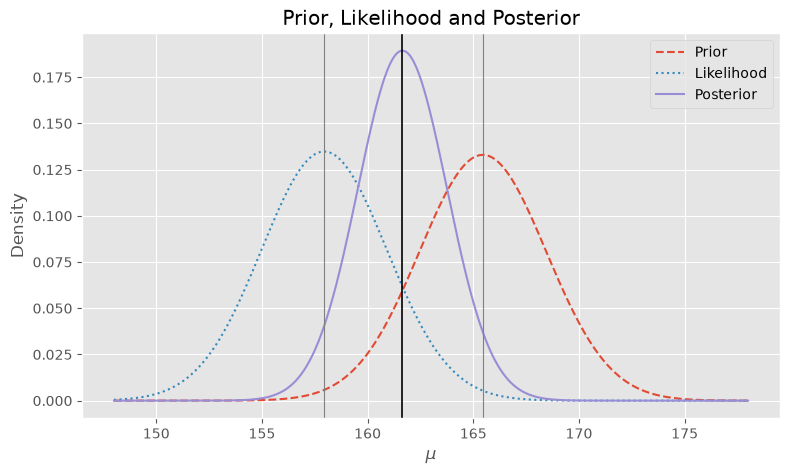

In [6]:
mu_grid = np.linspace(148, 178, 500)

prior_pdf = stats.norm.pdf(mu_grid, loc=prior_mean, scale=prior_std)

xbar = small_city_data.mean()
se = small_city_data.std() / np.sqrt(len(small_city_data))
likelihood_pdf = stats.norm.pdf(mu_grid, loc=xbar, scale=se)

posterior_pdf = stats.norm.pdf(mu_grid, loc=posterior_mean, scale=posterior_std)

plt.figure(figsize=(9, 5))
plt.plot(mu_grid, prior_pdf, linestyle="--", label="Prior")
plt.plot(mu_grid, likelihood_pdf, linestyle=":", label="Likelihood")
plt.plot(mu_grid, posterior_pdf, label="Posterior")
plt.axvline(prior_mean, color="gray", linewidth=0.8)
plt.axvline(xbar, color="gray", linewidth=0.8)
plt.axvline(posterior_mean, color="black", linewidth=1.2)
plt.xlabel(r"$\mu$")
plt.ylabel("Density")
plt.title("Prior, Likelihood and Posterior")
plt.legend()
plt.show()


### Inference with a Small Sample

In frequentist statistics it is generally recommended to have at least 30 samples. We can work with less, but we have to accept the decreased statistical power (finding evidence when there actually is evidence) and reliability.

In Bayesian statistics we do not have such a rule. As long as we have strong prior knowledge, we can still get robust results. Our small city has only 12 measurements, so let's compare the plain frequentist interval with the Bayesian one that uses the country prior.


In [7]:
n = len(small_city_data)
x_bar = small_city_data.mean()
s = small_city_data.std(ddof=1)
se = s / np.sqrt(n)

t_crit = stats.t.ppf(0.975, df=n - 1)
freq_lower = x_bar - t_crit * se
freq_upper = x_bar + t_crit * se

cred_lower = stats.norm.ppf(0.025, loc=posterior_mean, scale=posterior_std)
cred_upper = stats.norm.ppf(0.975, loc=posterior_mean, scale=posterior_std)

print(f"95% Confidence Interval (frequentist): ({freq_lower:.2f}, {freq_upper:.2f}) cm")
print(f"95% Credible Interval (Bayesian):      ({cred_lower:.2f}, {cred_upper:.2f}) cm")

95% Confidence Interval (frequentist): (151.14, 164.75) cm
95% Credible Interval (Bayesian):      (157.52, 165.78) cm


### Credible Interval

If you noticed, we denoted the resulting interval as "Credible Interval" not "Confidence Interval". They are similar but they tell us different things. For example a 95% confidence interval indicates that if we repeat the same experiment over and over again, 95% of the experiment results lie in the proposed range. On the other hand, 95% credible interval indicates that there is a 95% probability that the true value of the parameter lies within the specified range.

There are infinitely many ways to obtain 95% area of a distribution. The narrowest range giving the 95% of the distribution area is called *Highest Density Interval* (HDI). In symmetric distributions, we use percentiles to obtain HDI. On the other hand, for multimodal distributions the HDI can refer to a combination of two or more areas.

## Computing the Posterior Numerically

What if the prior is not conjugate? How could we combine distributions?

There are 3 ways to do that:

- Grid method
- Quadratic Method
- Markov Chain Monte Carlo


### Grid Method

The grid method evaluates the unnormalized posterior at many candidate values and then normalizes. Here are the steps:

1. Create a fine grid of $\mu$ values.
2. For each $\mu$, compute the logarithm of the prior probability density. (Multiplication turns into sum in log scale, which makes calculations easier.)
3. For each $\mu$, compute the logarithm of the likelihood probability density.
4. Sum them up.
5. Determine the max of these summed values and subtract it from every one. (This is the actual numerical-stability trick, it keeps the numbers in a safe range before exponentiating, without changing the final normalized result.)
6. Convert back into numerical scale (exponentiate).
7. Normalize the obtained values so that they sum, or integrate, to 1.

In [8]:
# Grid of candidate mu values
mu_grid = np.linspace(148, 178, 1000)

# For each $\mu$, compute the logarithm of the prior probability density.
log_prior = stats.norm.logpdf(mu_grid, loc=prior_mean, scale=prior_std)

# For each $\mu$, compute the logarithm of the likelihood probability density.
log_likelihood = np.array([
    stats.norm.logpdf(small_city_data, loc=mu, scale=obs_std).sum()
    for mu in mu_grid
])

# Sum them up.
log_posterior = log_prior + log_likelihood

# Determine the max of these summed values and subtract it from every one.
# Convert back into numerical scale (exponentiate). 
# Normalize the obtained values so that they sum, or integrate, to 1.
log_posterior -= log_posterior.max()
posterior_grid = np.exp(log_posterior)
posterior_grid /= posterior_grid.sum() * (mu_grid[1] - mu_grid[0])  # normalize to density

# Posterior mean and std from the grid
grid_mean = np.sum(mu_grid * posterior_grid) * (mu_grid[1] - mu_grid[0])
grid_std = np.sqrt(np.sum((mu_grid - grid_mean)**2 * posterior_grid) * (mu_grid[1] - mu_grid[0]))

print(f'Grid posterior mean: {grid_mean:.2f} cm')
print(f'Grid posterior std:  {grid_std:.2f} cm')


Grid posterior mean: 161.65 cm
Grid posterior std:  2.11 cm


### Quadratic Method

Also called the **Laplace approximation**. The idea:

1. Find the mode of the log-posterior (the MAP estimate) using optimization
2. Compute the curvature (second derivative) of the log-posterior at the mode
3. Approximate the posterior as a Gaussian centered at the mode, with variance determined by the curvature:

$\mu_{\text{post}} = \hat{\theta}_{\text{MAP}}$

$\sigma_{\text{post}}^2 = \left( -\frac{d^2}{d\theta^2} \log P(\theta \mid D) \Big|_{\theta=\hat{\theta}} \right)^{-1}$

This works well when the posterior is approximately bell-shaped (unimodal and symmetric).

In [9]:

# Define the negative log-posterior as a function of mu
def neg_log_posterior(mu):
    lp = stats.norm.logpdf(mu, loc=prior_mean, scale=prior_std)
    ll = stats.norm.logpdf(small_city_data, loc=mu, scale=obs_std).sum()
    return -(lp + ll)

# Step 1: Find the MAP (mode of posterior)
result = minimize_scalar(neg_log_posterior, bounds=(148, 178), method='bounded')
map_estimate = result.x

# Step 2: Curvature at the MAP (second derivative via finite differences)
dx = 1e-4
hessian = (neg_log_posterior(map_estimate + dx) - 2*neg_log_posterior(map_estimate) + neg_log_posterior(map_estimate - dx)) / dx**2
quad_std = np.sqrt(1 / hessian)

print(f'Quadratic posterior mean (MAP): {map_estimate:.2f} cm')
print(f'Quadratic posterior std:        {quad_std:.2f} cm')


Quadratic posterior mean (MAP): 161.65 cm
Quadratic posterior std:        2.11 cm


### Markov Chain Monte Carlo (MCMC)

MCMC is the last way to obtain the posterior. For the mathematics, you can refer to [this](https://www.youtube.com/watch?v=yApmR-c_hKU) video.

In Python, we can use the `pymc` library for this purpose.

In [10]:
with pm.Model() as height_model:
    
    mu = pm.Normal('mu', mu=prior_mean, sigma=prior_std)
    likelihood = pm.Normal('obs', mu=mu, sigma=obs_std, observed=small_city_data)
    trace = pm.sample(2000, tune=1000, random_seed=42, chains=2)

# Posterior summary
mcmc_mean = trace.posterior['mu'].mean().item()
mcmc_std = trace.posterior['mu'].std().item()

print(f'PyMC posterior mean: {mcmc_mean:.2f} cm')
print(f'PyMC posterior std:  {mcmc_std:.2f} cm')


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu]


c:\Users\egemen.u.dalgic\NEW\Applied-Statistics\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


PyMC posterior mean: 161.49 cm
PyMC posterior std:  2.10 cm


All three methods land on the same posterior, which gives us confidence in the machinery. We now know how to build a single Bayesian model, borrow or estimate its prior, and compute the posterior in several ways.

So far every model has rested on a single group of data with a prior handed to it. In the next notebook we go beyond that and let many groups share information, which leads to Empirical Bayes and hierarchical models.